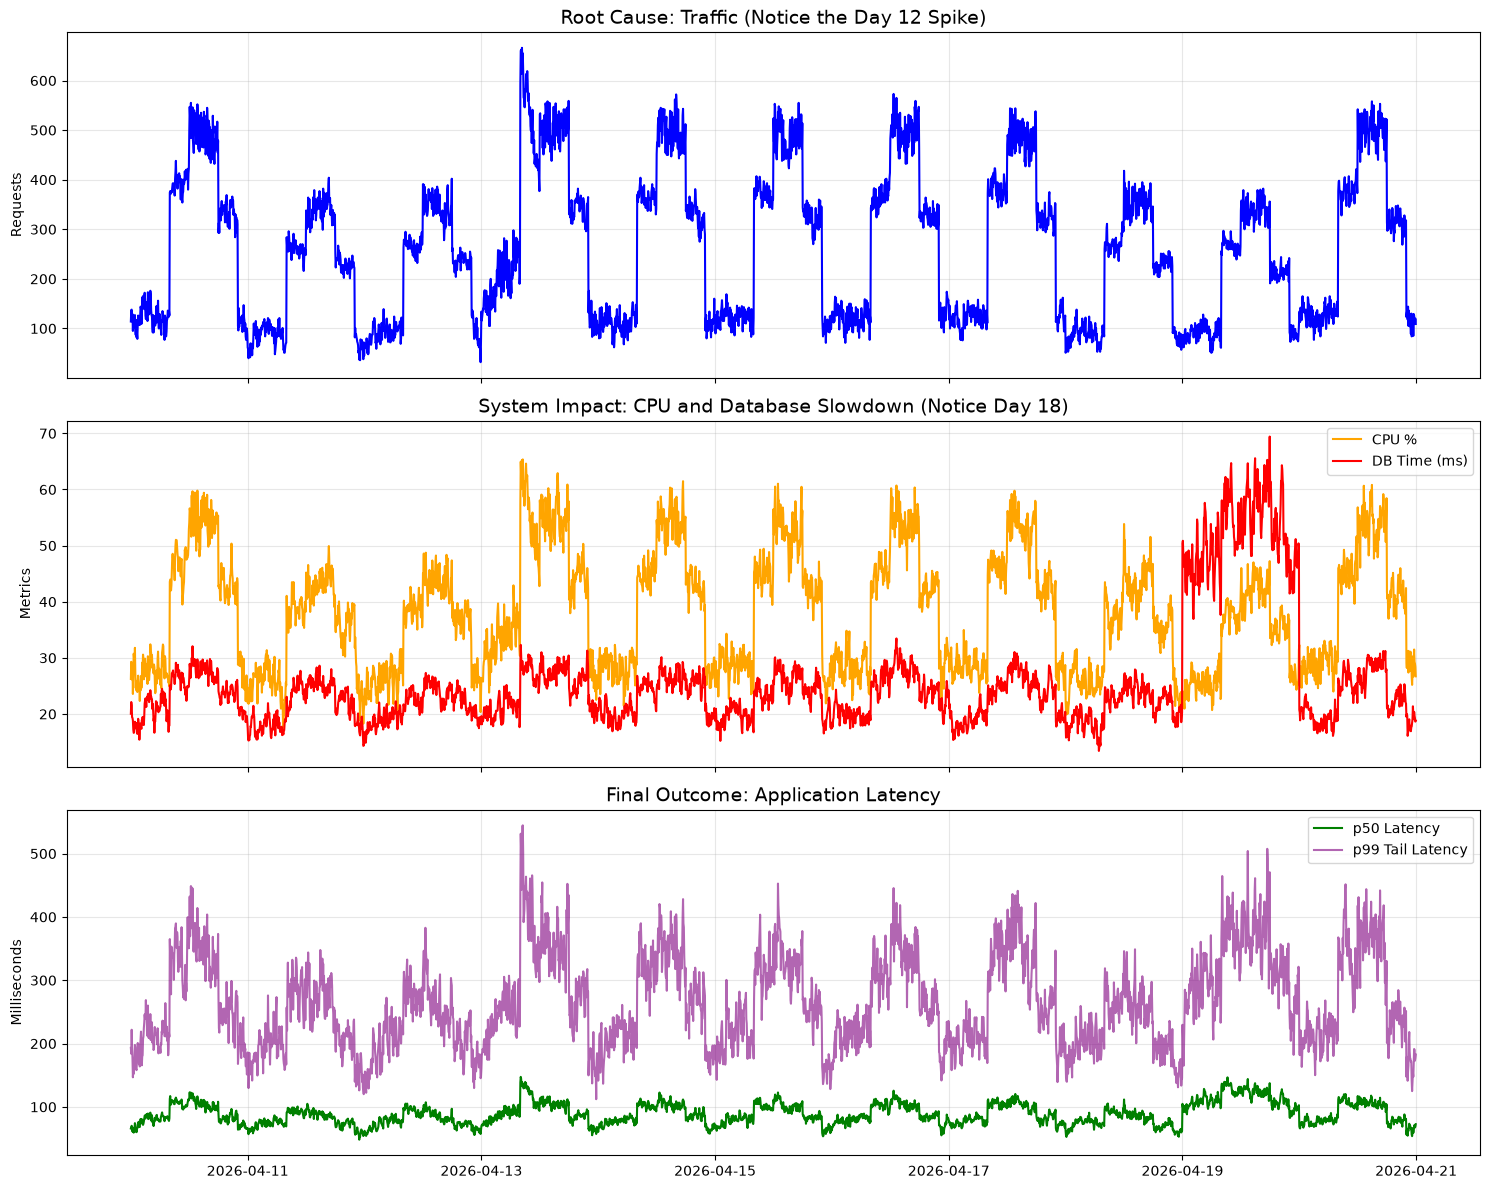

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Load the data
df = pd.read_csv('DataSets/latency_data_production_grade.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

#Checkin Days 10 through 20 to see the Traffic Spike and DB Slowdown
subset = df.loc['2026-04-10':'2026-04-20']

#Plot the Causal Chain
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

#Plot Traffic
ax1.plot(subset.index, subset['request_count'], color='blue')
ax1.set_title('Root Cause: Traffic (Notice the Day 12 Spike)', fontsize=14)
ax1.set_ylabel('Requests')
ax1.grid(True, alpha=0.3)

#Plot CPU & Database Time
ax2.plot(subset.index, subset['cpu_usage'], color='orange', label='CPU %')
ax2.plot(subset.index, subset['db_query_time_ms'], color='red', label='DB Time (ms)')
ax2.set_title('System Impact: CPU and Database Slowdown (Notice Day 18)', fontsize=14)
ax2.set_ylabel('Metrics')
ax2.legend()
ax2.grid(True, alpha=0.3)

#Plot Latency
ax3.plot(subset.index, subset['p50_latency_ms'], color='green', label='p50 Latency')
ax3.plot(subset.index, subset['p99_latency_ms'], color='purple', alpha=0.6, label='p99 Tail Latency')
ax3.set_title('Final Outcome: Application Latency', fontsize=14)
ax3.set_ylabel('Milliseconds')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()